In [ ]:
import os
import sys
# Jupyter kernels start in the notebook's directory; move up to repo root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


# Epoch Selection via Train-Loss Early Stopping

**Goal**: Find a good `min_delta` threshold for early stopping on train loss. Because the
number of training points changes every AL iteration (and varies across datasets), a fixed
`max_epochs` will over- or under-train. Training until the per-epoch change in train loss
falls below a threshold `min_delta` is a simple, data-size-agnostic stopping rule.

**Approach**
1. For each of the four dataset × model-type combinations (PXR/ASAP × CheMeleon/ChemProp),
   sample training subsets at several sizes spanning the AL range.
2. Train a **single model** (no ensemble) to `MAX_EPOCHS` epochs, logging train loss and
   val loss every epoch via the CSVLogger.
3. **Post-hoc simulate** EarlyStopping with `monitor=train_loss`, varying `min_delta` and
   a fixed `patience`, to find which `min_delta` gives a good val-loss stopping point.
4. Recommend a single `min_delta` value to use across all configs.

In [1]:
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.helpers import build_committee_member, featurize
from src.config import load_config

warnings.filterwarnings("ignore")

## Configuration

In [2]:
# ── Experiment parameters ─────────────────────────────────────────────────────
MAX_EPOCHS = 100  # Train to this ceiling so we can see the full loss curve
VAL_FRAC = 0.2  # Fraction of data held out for val-loss evaluation
SEED = 42
PATIENCE = 5  # Patience (in epochs) for the simulated early stopping
ACCELERATOR = "mps"  # Change to "cpu" if no GPU available

# min_delta values to simulate (change in train loss must be < delta to count as no improvement)
DELTA_CANDIDATES = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

# ── Experiments: one row per (dataset × model_type) combo ────────────────────
# n_sizes: training set sizes to probe within each experiment
EXPERIMENTS = [
    dict(
        label="PXR · CheMeleon",
        config="config/pxr_chemeleon_config.yaml",
        use_chemeleon=True,
        n_sizes=[100, 500, 1000, 3000],
    ),
    dict(
        label="PXR · ChemProp",
        config="config/pxr_chemprop_config.yaml",
        use_chemeleon=False,
        n_sizes=[100, 500, 1000, 3000],
    ),
    dict(
        label="ASAP · CheMeleon",
        config="config/asap_chemeleon_config.yaml",
        use_chemeleon=True,
        n_sizes=[100, 500, 1000],
    ),
    dict(
        label="ASAP · ChemProp",
        config="config/asap_chemprop_config.yaml",
        use_chemeleon=False,
        n_sizes=[100, 500, 1000],
    ),
]

## Helper functions

In [3]:
def load_dataset(cfg_path: str) -> pd.DataFrame:
    """Load and rename the dataset described by a config file."""
    cfg = load_config(cfg_path)
    path = Path(cfg.dataset_path).expanduser()
    if path.suffix == ".parquet":
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path)
    df = df.rename(
        columns={cfg.dataset_smiles_col: "smiles", cfg.dataset_activity_col: "y"}
    )
    df = df[["smiles", "y"]].dropna()
    return df


def train_single_model(
    smiles_train,
    y_train,
    smiles_val,
    y_val,
    use_chemeleon: bool,
    max_epochs: int,
    seed: int,
    accelerator: str,
) -> pd.DataFrame:
    """Train one model and return a DataFrame with epoch-level train/val loss."""
    with tempfile.TemporaryDirectory(prefix="epoch_sel_") as tmp:
        tmp_path = Path(tmp)
        model, trainer = build_committee_member(
            seed=seed,
            max_epochs=max_epochs,
            log_dir=tmp_path,
            use_chemeleon=use_chemeleon,
        )
        trainer.accelerator = accelerator
        trainer.early_stopping = (
            False  # train to max_epochs; we simulate stopping post-hoc
        )

        train_loader, scaler = featurize(smiles_train, y_train, shuffle=True)
        val_loader, _ = featurize(smiles_val, y_val, shuffle=False)

        model.build(scaler=scaler)
        trainer.build(no_val=False)  # enables val_loss logging
        trainer.train(train_loader, val_loader)

        # CSVLogger writes to: output_dir/logs/model/version_0/metrics.csv
        csv_files = list(tmp_path.glob("logs/model/version_*/metrics.csv"))
        if not csv_files:
            raise FileNotFoundError(f"metrics.csv not found under {tmp_path}")
        metrics = pd.read_csv(csv_files[0])

    # CSVLogger interleaves train and val rows (different steps per epoch).
    # Merge them on epoch using the correct column name train_loss_epoch.
    train_ep = (
        metrics[["epoch", "train_loss_epoch"]]
        .dropna(subset=["train_loss_epoch"])
        .groupby("epoch")["train_loss_epoch"]
        .mean()
        .reset_index()
        .rename(columns={"train_loss_epoch": "train_loss"})
    )
    val_ep = (
        metrics[["epoch", "val_loss"]]
        .dropna(subset=["val_loss"])
        .groupby("epoch")["val_loss"]
        .mean()
        .reset_index()
    )
    epoch_metrics = (
        train_ep.merge(val_ep, on="epoch").sort_values("epoch").reset_index(drop=True)
    )
    return epoch_metrics


def simulate_early_stopping(
    train_loss: np.ndarray, min_delta: float, patience: int
) -> int:
    """Return the epoch index where early stopping would trigger.

    'Improvement' is defined as a decrease in train_loss of at least min_delta.
    Returns len(train_loss)-1 if training never converges.
    """
    best = train_loss[0]
    wait = 0
    for epoch, loss in enumerate(train_loss):
        if best - loss > min_delta:
            best = loss
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            return epoch
    return len(train_loss) - 1

## Run training and collect loss curves

For each (experiment × N) combination, we do an 80/20 random split and train one model.

In [ ]:
results = {}  # key: (label, n_train) -> epoch_metrics DataFrame

for exp in EXPERIMENTS:
    print(f"\n{'=' * 60}")
    print(f"  {exp['label']}")
    print(f"{'=' * 60}")

    df = load_dataset(exp["config"])
    print(f"  Dataset size: {len(df)}")

    rng = np.random.RandomState(SEED)

    for n in exp["n_sizes"]:
        if n > len(df):
            print(f"  Skipping N={n} (dataset too small)")
            continue

        # Sample n compounds, then 80/20 split
        idx = rng.choice(len(df), size=n, replace=False)
        df_sub = df.iloc[idx].reset_index(drop=True)

        n_val = max(1, int(n * VAL_FRAC))
        val_idx = rng.choice(n, size=n_val, replace=False)
        train_idx = np.setdiff1d(np.arange(n), val_idx)

        smiles_train = df_sub.loc[train_idx, "smiles"].values
        y_train = df_sub.loc[train_idx, "y"].values
        smiles_val = df_sub.loc[val_idx, "smiles"].values
        y_val = df_sub.loc[val_idx, "y"].values

        print(
            f"  N={n}: {len(smiles_train)} train / {len(smiles_val)} val ... ",
            end="",
            flush=True,
        )
        epoch_metrics = train_single_model(
            smiles_train,
            y_train,
            smiles_val,
            y_val,
            use_chemeleon=exp["use_chemeleon"],
            max_epochs=MAX_EPOCHS,
            seed=SEED,
            accelerator=ACCELERATOR,
        )
        results[(exp["label"], n)] = epoch_metrics
        final_epoch = epoch_metrics["epoch"].max()
        print(f"done ({final_epoch + 1} epochs logged)")

## Simulate early stopping and plot loss curves

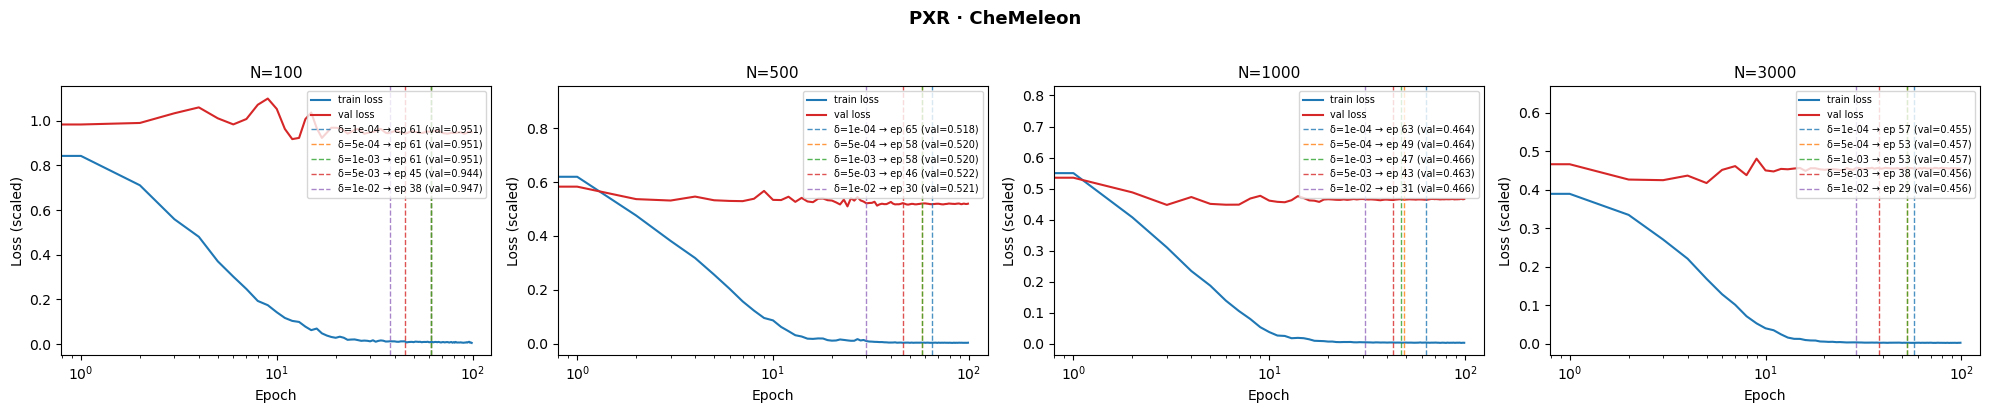

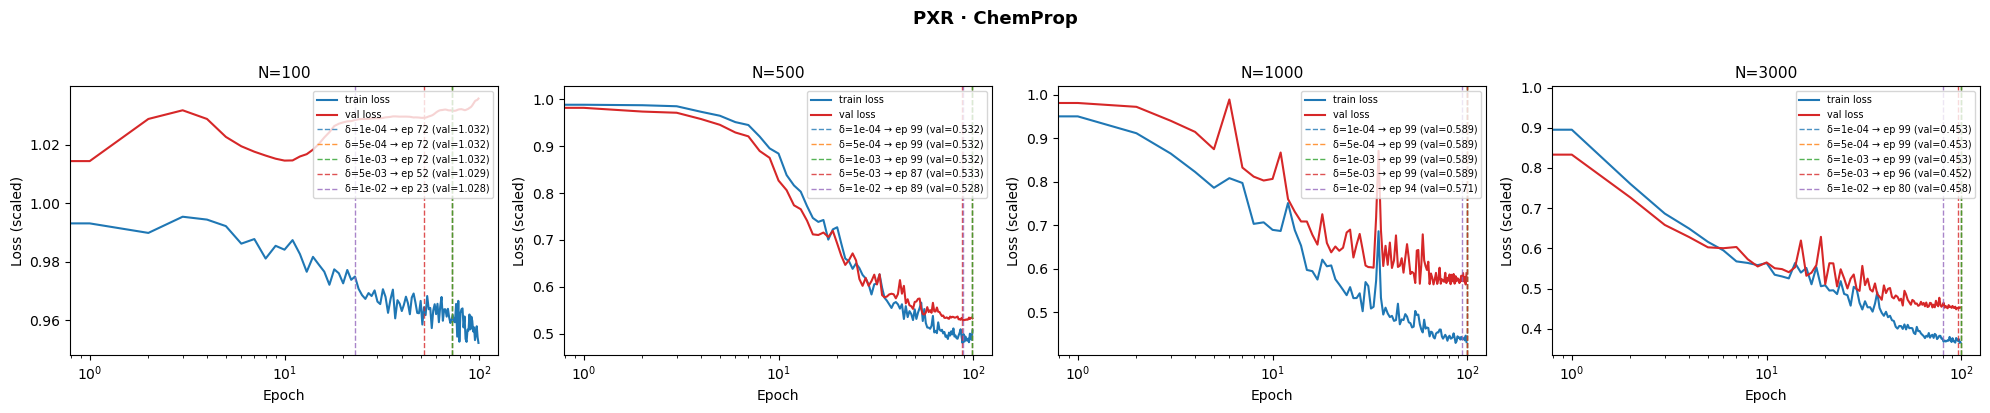

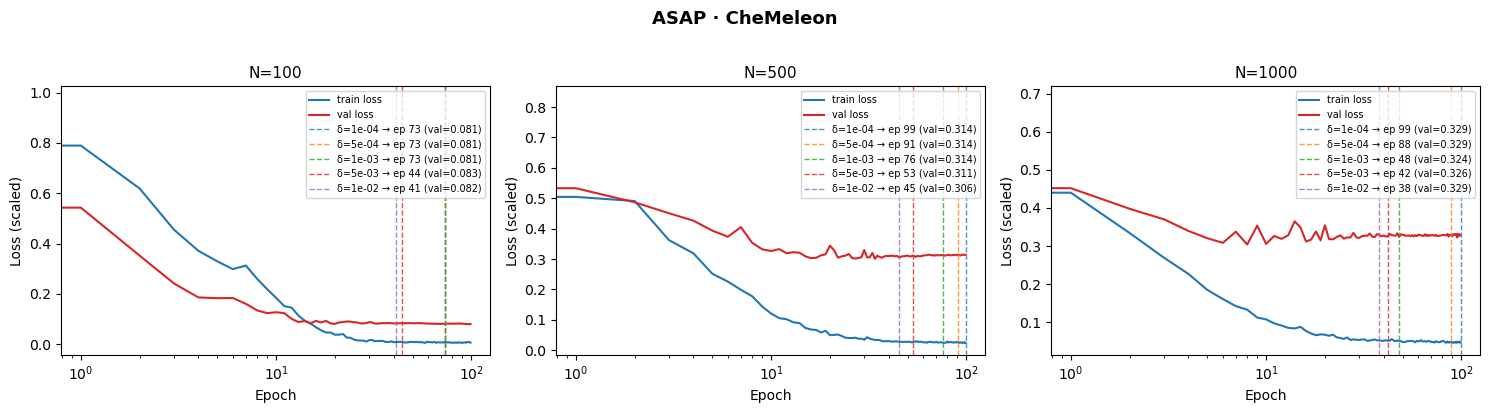

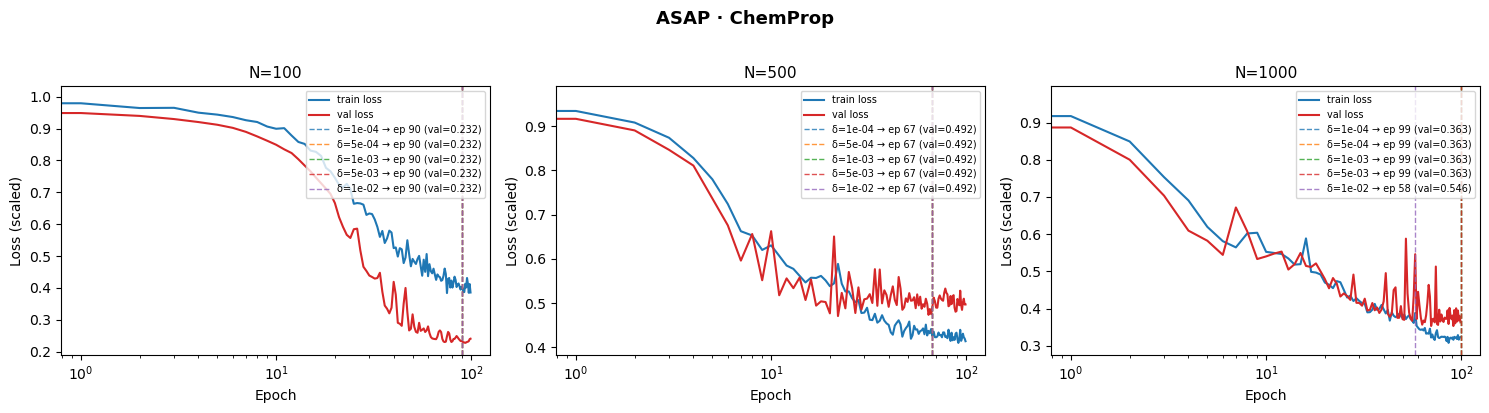

In [ ]:
COLORS = plt.cm.tab10.colors

PATIENCE = 15

for exp in EXPERIMENTS:
    n_sizes_run = [n for n in exp["n_sizes"] if (exp["label"], n) in results]
    if not n_sizes_run:
        continue

    n_panels = len(n_sizes_run)
    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4), sharey=False)
    if n_panels == 1:
        axes = [axes]

    fig.suptitle(exp["label"], fontsize=13, fontweight="bold", y=1.02)

    for ax, n in zip(axes, n_sizes_run):
        em = results[(exp["label"], n)]
        epochs = em["epoch"].values
        train_loss = em["train_loss"].values
        val_loss = em["val_loss"].values

        ax.plot(epochs, train_loss, color="C0", lw=1.5, label="train loss")
        ax.plot(epochs, val_loss, color="C3", lw=1.5, label="val loss")

        # Simulate and annotate each min_delta
        for i, delta in enumerate(DELTA_CANDIDATES):
            stop_epoch = simulate_early_stopping(
                train_loss, min_delta=delta, patience=PATIENCE
            )
            stop_val = (
                val_loss[stop_epoch] if stop_epoch < len(val_loss) else val_loss[-1]
            )
            ax.axvline(
                stop_epoch,
                color=COLORS[i],
                lw=1,
                linestyle="--",
                alpha=0.8,
                label=f"δ={delta:.0e} → ep {stop_epoch} (val={stop_val:.3f})",
            )

        ax.set_title(f"N={n}", fontsize=11)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss (scaled)")

        # ax.axvline(30, color="black", linewidth=1, linestyle="--", label="Epoch 30")

        ax.legend(fontsize=7, loc="upper right")

        ax.set_xscale("log")

    plt.tight_layout()
    plt.show()

## Summary table: stopping epoch and val loss per (experiment, N, delta)

In [ ]:
rows = []
for (label, n), em in results.items():
    train_loss = em["train_loss"].values
    val_loss = em["val_loss"].values
    val_loss_at_max = val_loss[-1]

    dataset, model = label.split(" · ")

    for delta in DELTA_CANDIDATES:
        for patience in [5, 10, 15, 20]:
            stop_ep = simulate_early_stopping(
                train_loss, min_delta=delta, patience=patience
            )
            stop_val = val_loss[stop_ep] if stop_ep < len(val_loss) else val_loss[-1]
            rows.append(
                dict(
                    dataset=dataset,
                    model=model,
                    N=n,
                    min_delta=delta,
                    patience=patience,
                    stop_epoch=stop_ep,
                    val_loss_at_stop=round(stop_val, 4),
                    val_loss_at_max=round(val_loss_at_max, 4),
                    val_loss_diff=round(stop_val - val_loss_at_max, 4),
                )
            )

summary = pd.DataFrame(rows)
pd.set_option("display.max_rows", 200)
summary

,dataset,model,N,min_delta,patience,stop_epoch,val_loss_at_stop,val_loss_at_max,val_loss_diff
0,PXR,CheMeleon,100,0.0001,5,37,0.9440,0.9479,-0.0039
1,PXR,CheMeleon,100,0.0001,10,56,0.9459,0.9479,-0.0020
2,PXR,CheMeleon,100,0.0001,15,61,0.9509,0.9479,0.0030
3,PXR,CheMeleon,100,0.0001,20,66,0.9542,0.9479,0.0063
4,PXR,CheMeleon,100,0.0005,5,37,0.9440,0.9479,-0.0039
...,...,...,...,...,...,...,...,...,...
275,ASAP,ChemProp,1000,0.0050,20,99,0.3627,0.3627,0.0000
276,ASAP,ChemProp,1000,0.0100,5,38,0.3880,0.3627,0.0253
277,ASAP,ChemProp,1000,0.0100,10,53,0.4405,0.3627,0.0778
278,ASAP,ChemProp,1000,0.0100,15,58,0.5460,0.3627,0.1832


In [ ]:
from scipy import stats

summary[summary["N"] == 100].groupby(by=["min_delta", "patience"])[
    ["val_loss_at_stop", "stop_epoch"]
].agg({"val_loss_at_stop": stats.hmean, "stop_epoch": "mean"}).sort_values(
    by="val_loss_at_stop"
)

,,val_loss_at_stop,stop_epoch
min_delta,patience,,
0.0001,15,0.214083,74.00
0.0005,15,0.214083,74.00
0.0010,15,0.214083,74.00
0.0001,20,0.215322,84.50
0.0005,20,0.215322,84.50
0.0010,20,0.215322,84.50
0.0100,15,0.216596,48.00
0.0050,15,0.218107,57.75
0.0100,20,0.218259,60.25


## Recommendation

Look for the smallest `min_delta` that consistently stops before the val loss starts rising
(or plateaus past its minimum), across all N and both datasets.

- `val_loss_diff` ≈ 0 → stopped near the optimal epoch  
- `val_loss_diff` > 0 → stopped too early (val could still improve)  
- `stop_epoch` ≈ `MAX_EPOCHS − 1` → never triggered (delta too tight)

Once you have chosen a `min_delta`, update `src/helpers.py → build_committee_member` to pass
```python
early_stopping=True,
early_stopping_patience=PATIENCE,
early_stopping_min_delta=CHOSEN_DELTA,
```
to `LightningTrainer`, and set `max_epochs` to a safe ceiling (e.g. 200) in all configs.